# Intent Classifier — Model Comparison
**Role 5: NLP / Intent Classifier**

Uses the existing `extract_features()` and `train_all()` from `src/intent/` (unchanged) — this notebook adds the missing evaluation: F1 comparison across all 4 models, a confusion matrix, and selection of the best model.

In [14]:
import sys, os
sys.path.append(os.path.abspath(".."))  # so src/ imports work from notebooks/

from src.intent.features import extract_features
from src.intent.train import train_all
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import joblib

## 1. Load labeled data
Replace `samples` below with the real dataset from `data/` once you locate it (e.g. `pd.read_csv("../data/processed/intent_labels.csv")`). Starting with the known example set so the pipeline runs end-to-end today.

In [15]:
import pandas as pd
df = pd.read_csv("../data/processed/synthetic_intent_dataset.csv")
print(df.shape)
print(df["intent"].value_counts())
df.head()

(1000, 8)
intent
SEND_MONEY       200
BUY_BUNDLES      200
BUY_AIRTIME      200
PAY_BILL         200
CHECK_BALANCE    200
Name: count, dtype: int64


,id,transcript,intent,amount,recipient,service,ussd_sequence,is_synthetic
0,syn_0916,Niaje Weka elfu moja kwa 0798765432,SEND_MONEY,1000.0,0798765432,NaN,*334# -> 1 -> 0798765432 -> 1000,True
1,syn_0571,Weka cash Ksh 500 hapa brathe,SEND_MONEY,500.0,brathe,NaN,*334# -> 1 -> brathe -> 500,True
2,syn_0569,Buy bundles za mbao kwa 0712345678,BUY_BUNDLES,20.0,0712345678,NaN,*334# -> 3 -> 2 -> 20,True
3,syn_0697,Send airtime ya soo mbili,BUY_AIRTIME,200.0,NaN,NaN,*334# -> 3 -> 1 -> [RECIPIENT] -> 200,True
4,syn_0591,Tuma bob mbao kwa shosh,SEND_MONEY,20.0,shosh,NaN,*334# -> 1 -> shosh -> 20,True


In [16]:
from src.preprocessing.normalizer import load_slang_dictionary, normalize_text, clean_asr_output

slang_dict = load_slang_dictionary("../data/slang_dictionary/swahili_slang_typos.csv")

def preprocess(text):
    cleaned = clean_asr_output(text)
    return normalize_text(cleaned, slang_dict)

df["normalized"] = df["transcript"].apply(preprocess)
df[["transcript", "normalized", "intent"]].head(10)

,transcript,normalized,intent
0,Niaje Weka elfu moja kwa 0798765432,niaje weka elfu moja kwa 0798765432,SEND_MONEY
1,Weka cash Ksh 500 hapa brathe,weka cash ksh 500 hapa brother,SEND_MONEY
2,Buy bundles za mbao kwa 0712345678,buy bundles za 20 kwa 0712345678,BUY_BUNDLES
3,Send airtime ya soo mbili,send airtime ya 100 mbili,BUY_AIRTIME
4,Tuma bob mbao kwa shosh,tuma bob 20 kwa grandmother,SEND_MONEY
5,Lipa bill ya data Ksh 50,lipa bill ya data ksh 50,PAY_BILL
6,Tuma chapaa soo tano airtime line hii,tuma money 100 tano airtime line hii,BUY_AIRTIME
7,Nataka kuangalia balance kwa token,nataka kuangalia balance kwa token,CHECK_BALANCE
8,Balance ni gani kwa data,balance ni gani kwa data,CHECK_BALANCE
9,Lipia Zuku elfu 1500,lipia zuku elfu 1500,PAY_BILL


## 2. Feature extraction (existing function, unchanged)

In [17]:
texts = df["normalized"].tolist()
labels = df["intent"].tolist()

from src.intent.features import extract_features
from sklearn.model_selection import train_test_split

X, vectorizer = extract_features(texts)
X_train, X_val, y_train, y_val = train_test_split(
    X, labels, test_size=0.2, random_state=42, stratify=labels
)
X_train.shape, X_val.shape

((800, 559), (200, 559))

## 3. Train all 4 models (existing function, unchanged)

In [18]:
models = train_all(X_train, y_train, X_val, y_val, model_dir="../models/intent_classifier")

logistic_regression validation accuracy: 1.0000
decision_tree validation accuracy: 1.0000
random_forest validation accuracy: 1.0000
mlp validation accuracy: 1.0000


## 4. Model comparison — F1 score (the missing piece)
`train_all()` only prints accuracy. F1 is more reliable here since intents are imbalanced in small samples.

In [19]:
results = {}
for name, model in models.items():
    preds = model.predict(X_val)
    results[name] = f1_score(y_val, preds, average="weighted")

comparison_df = pd.DataFrame.from_dict(results, orient="index", columns=["f1_score"])
comparison_df = comparison_df.sort_values("f1_score", ascending=False)
comparison_df.to_csv("model_comparison.csv")
comparison_df

,f1_score
logistic_regression,1.0
decision_tree,1.0
random_forest,1.0
mlp,1.0


## 5. Best model + confusion matrix

Best model: logistic_regression (F1 = 1.000)


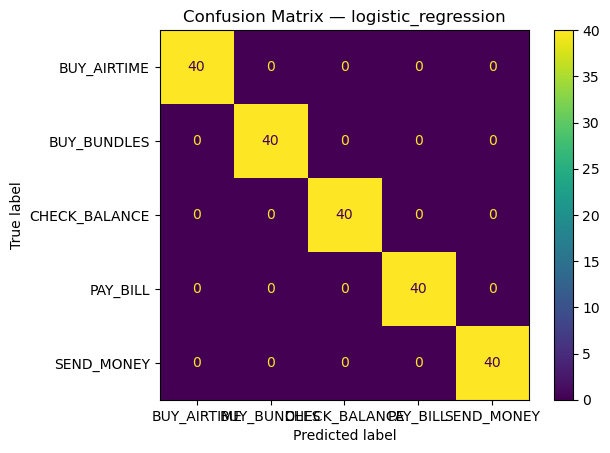

In [20]:
best_name = comparison_df.index[0]
best_model = models[best_name]
print(f"Best model: {best_name} (F1 = {comparison_df.iloc[0,0]:.3f})")

ConfusionMatrixDisplay.from_estimator(best_model, X_val, y_val)
plt.title(f"Confusion Matrix — {best_name}")
plt.savefig("intent_confusion_matrix.png", bbox_inches="tight")
plt.show()

## 6. Save vectorizer + record the winning model
`train.py` never saved the vectorizer — needed by `predict.py` and `pipeline.py`. This also records which model should be the pipeline default.

In [21]:
os.makedirs("../models", exist_ok=True)
joblib.dump(vectorizer, "../models/vectorizer.pkl")

os.makedirs("../models/intent_classifier", exist_ok=True)
with open("../models/intent_classifier/best_model.txt", "w") as f:
    f.write(best_name)

print("Saved vectorizer.pkl and best_model.txt")

Saved vectorizer.pkl and best_model.txt
